<center><h1> Three-Eloop </h1></center>

In [26]:
from MCA_lib1_2 import *
import pennylane as qml
import warnings
warnings.filterwarnings('ignore')

## Variables Input

In [27]:
# Number of desired symbols
num_ext_edges=4
num_int_edges=4
num_edges =num_ext_edges+num_int_edges

num_no_reverse_clauses = 5

num_propagator_edge = [2,2,2,2,1,1,1,1]

needs_extra_qubit = False

name_diagram = '4E12'

num_shots = 5000000
cut=500

## Logical Variables

In [28]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [29]:
# Definir auxiliares

######################## Loops - 3 propagators ######################

c[0] = And(S[0],S[5], Sp[4])
          
c[1] = And(S[1], S[6], Sp[5]) #5

c[2] = And(S[2], S[7], Sp[6]) #6

c[3] = And(S[3],S[4], Sp[7]) #7
        
######################## Loops - 4 propagators ######################


######################## exterior Loop  ######################

c[4] = And(S[0], S[1], S[2], S[3])


######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [30]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)
Graph_matrix_clauses

array([[0., 1., 0., 1., 0., 0., 0., 0.],
       [1., 0., 1., 0., 0., 1., 0., 0.],
       [0., 1., 0., 1., 0., 0., 1., 0.],
       [1., 0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1., 1., 0., 1.],
       [0., 0., 0., 1., 1., 0., 1., 0.]])

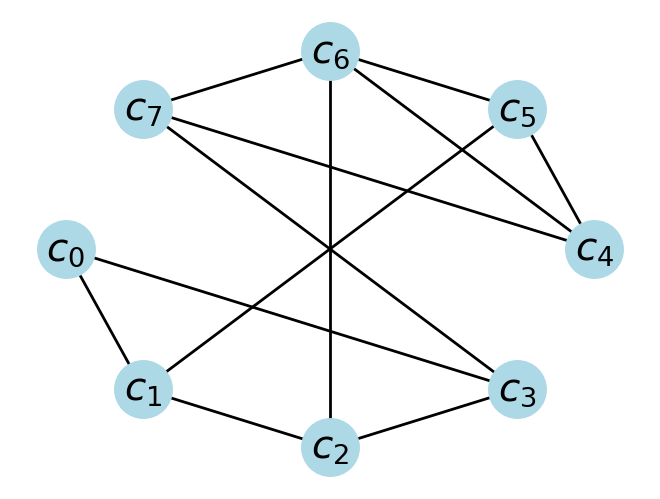

In [31]:
graph_clauses = graph_clauses(clauses, Set_edges, draw = True, name_graph = '3e9_clauses')

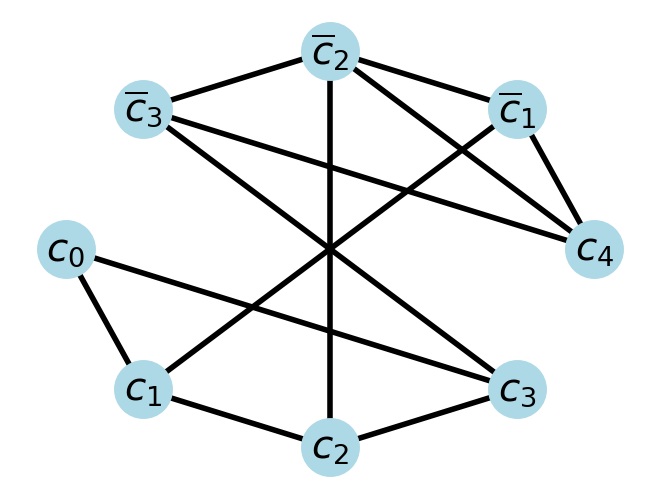

In [32]:
graph_clausesR = graph_clauses_Rev(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_ClausesRev')

[[-2, 4, -1], [1, 0], [3, 2], [-3]]

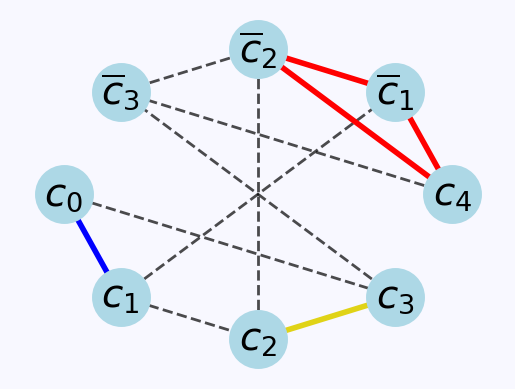

In [33]:
graph_clausesC = graph_clauses_C(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_Clauses_cliques')
graph_clausesC[1]

In [34]:
clauses_combination = Graph_condition_combination(graph_clauses,clauses,S,c)
clauses_combination

([[6, 4, 5], [1, 0], [3, 2], [7]], [[-2, 4, -1], [1, 0], [3, 2], [-3]])

## Depth

In [35]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)

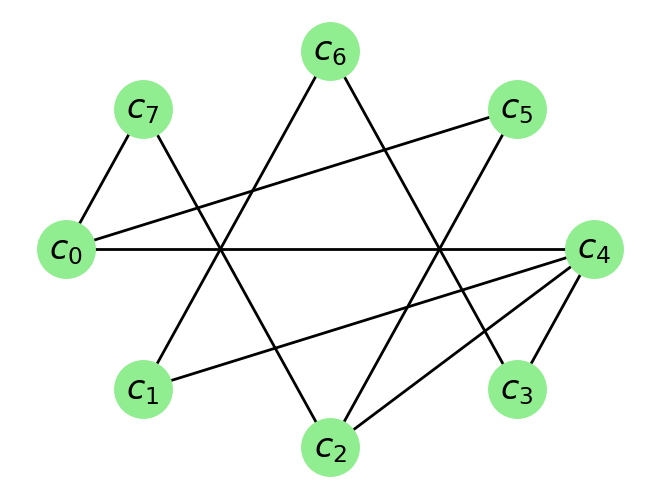

In [36]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

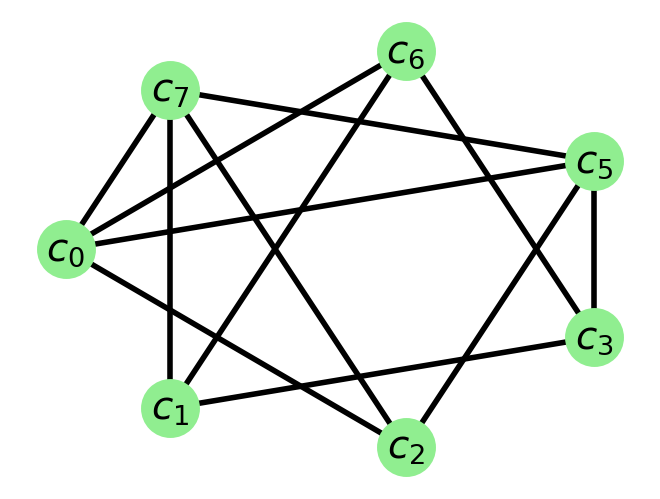

In [37]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

[[4], [0, 2, -1, -3], [1, 3, -2]]

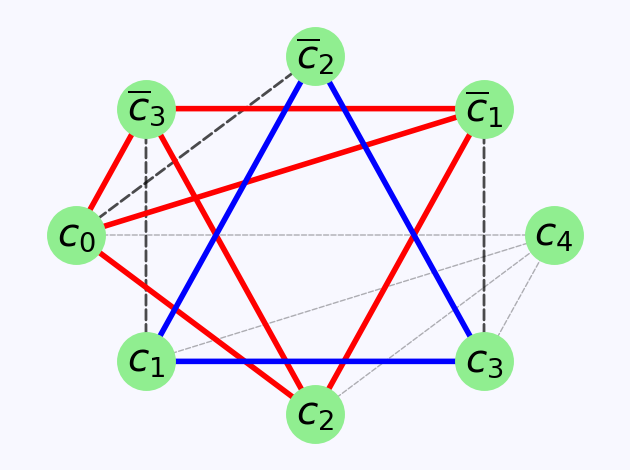

In [38]:
graph_depthf=graph_depthC(S,c,clauses,num_ext_edges,Set_edges, draw = True,name_graph = '3e9')
graph_depthf[1]

In [39]:
depth_combination = Graph_condition_combination(graph_depth,clauses,S,c)
depth_combination

([[4, 0], [1, 6], [2, 5], [3], [7]], [[4, 0], [1, -2], [2, -1], [3], [-3]])

In [40]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges,S,c)
depth_combination3
#[[3], [0, 4], [1, 5], [2]]


([[4], [0, 2, 5, 7], [1, 3, 6]], [[4], [0, 2, -1, -3], [1, 3, -2]])

<left><h2> Qubits </h2></left>

In [41]:
# Numbers of qubits to use
num_auxs = len(clauses_combination[0])

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination[0])

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [42]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)
qml.templates.GroverOperator.__name__ = "Diffusion Operator"

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [43]:
circuit3 = circuit_function([[4], [0, 2, 5, 7], [1, 3, 6]])

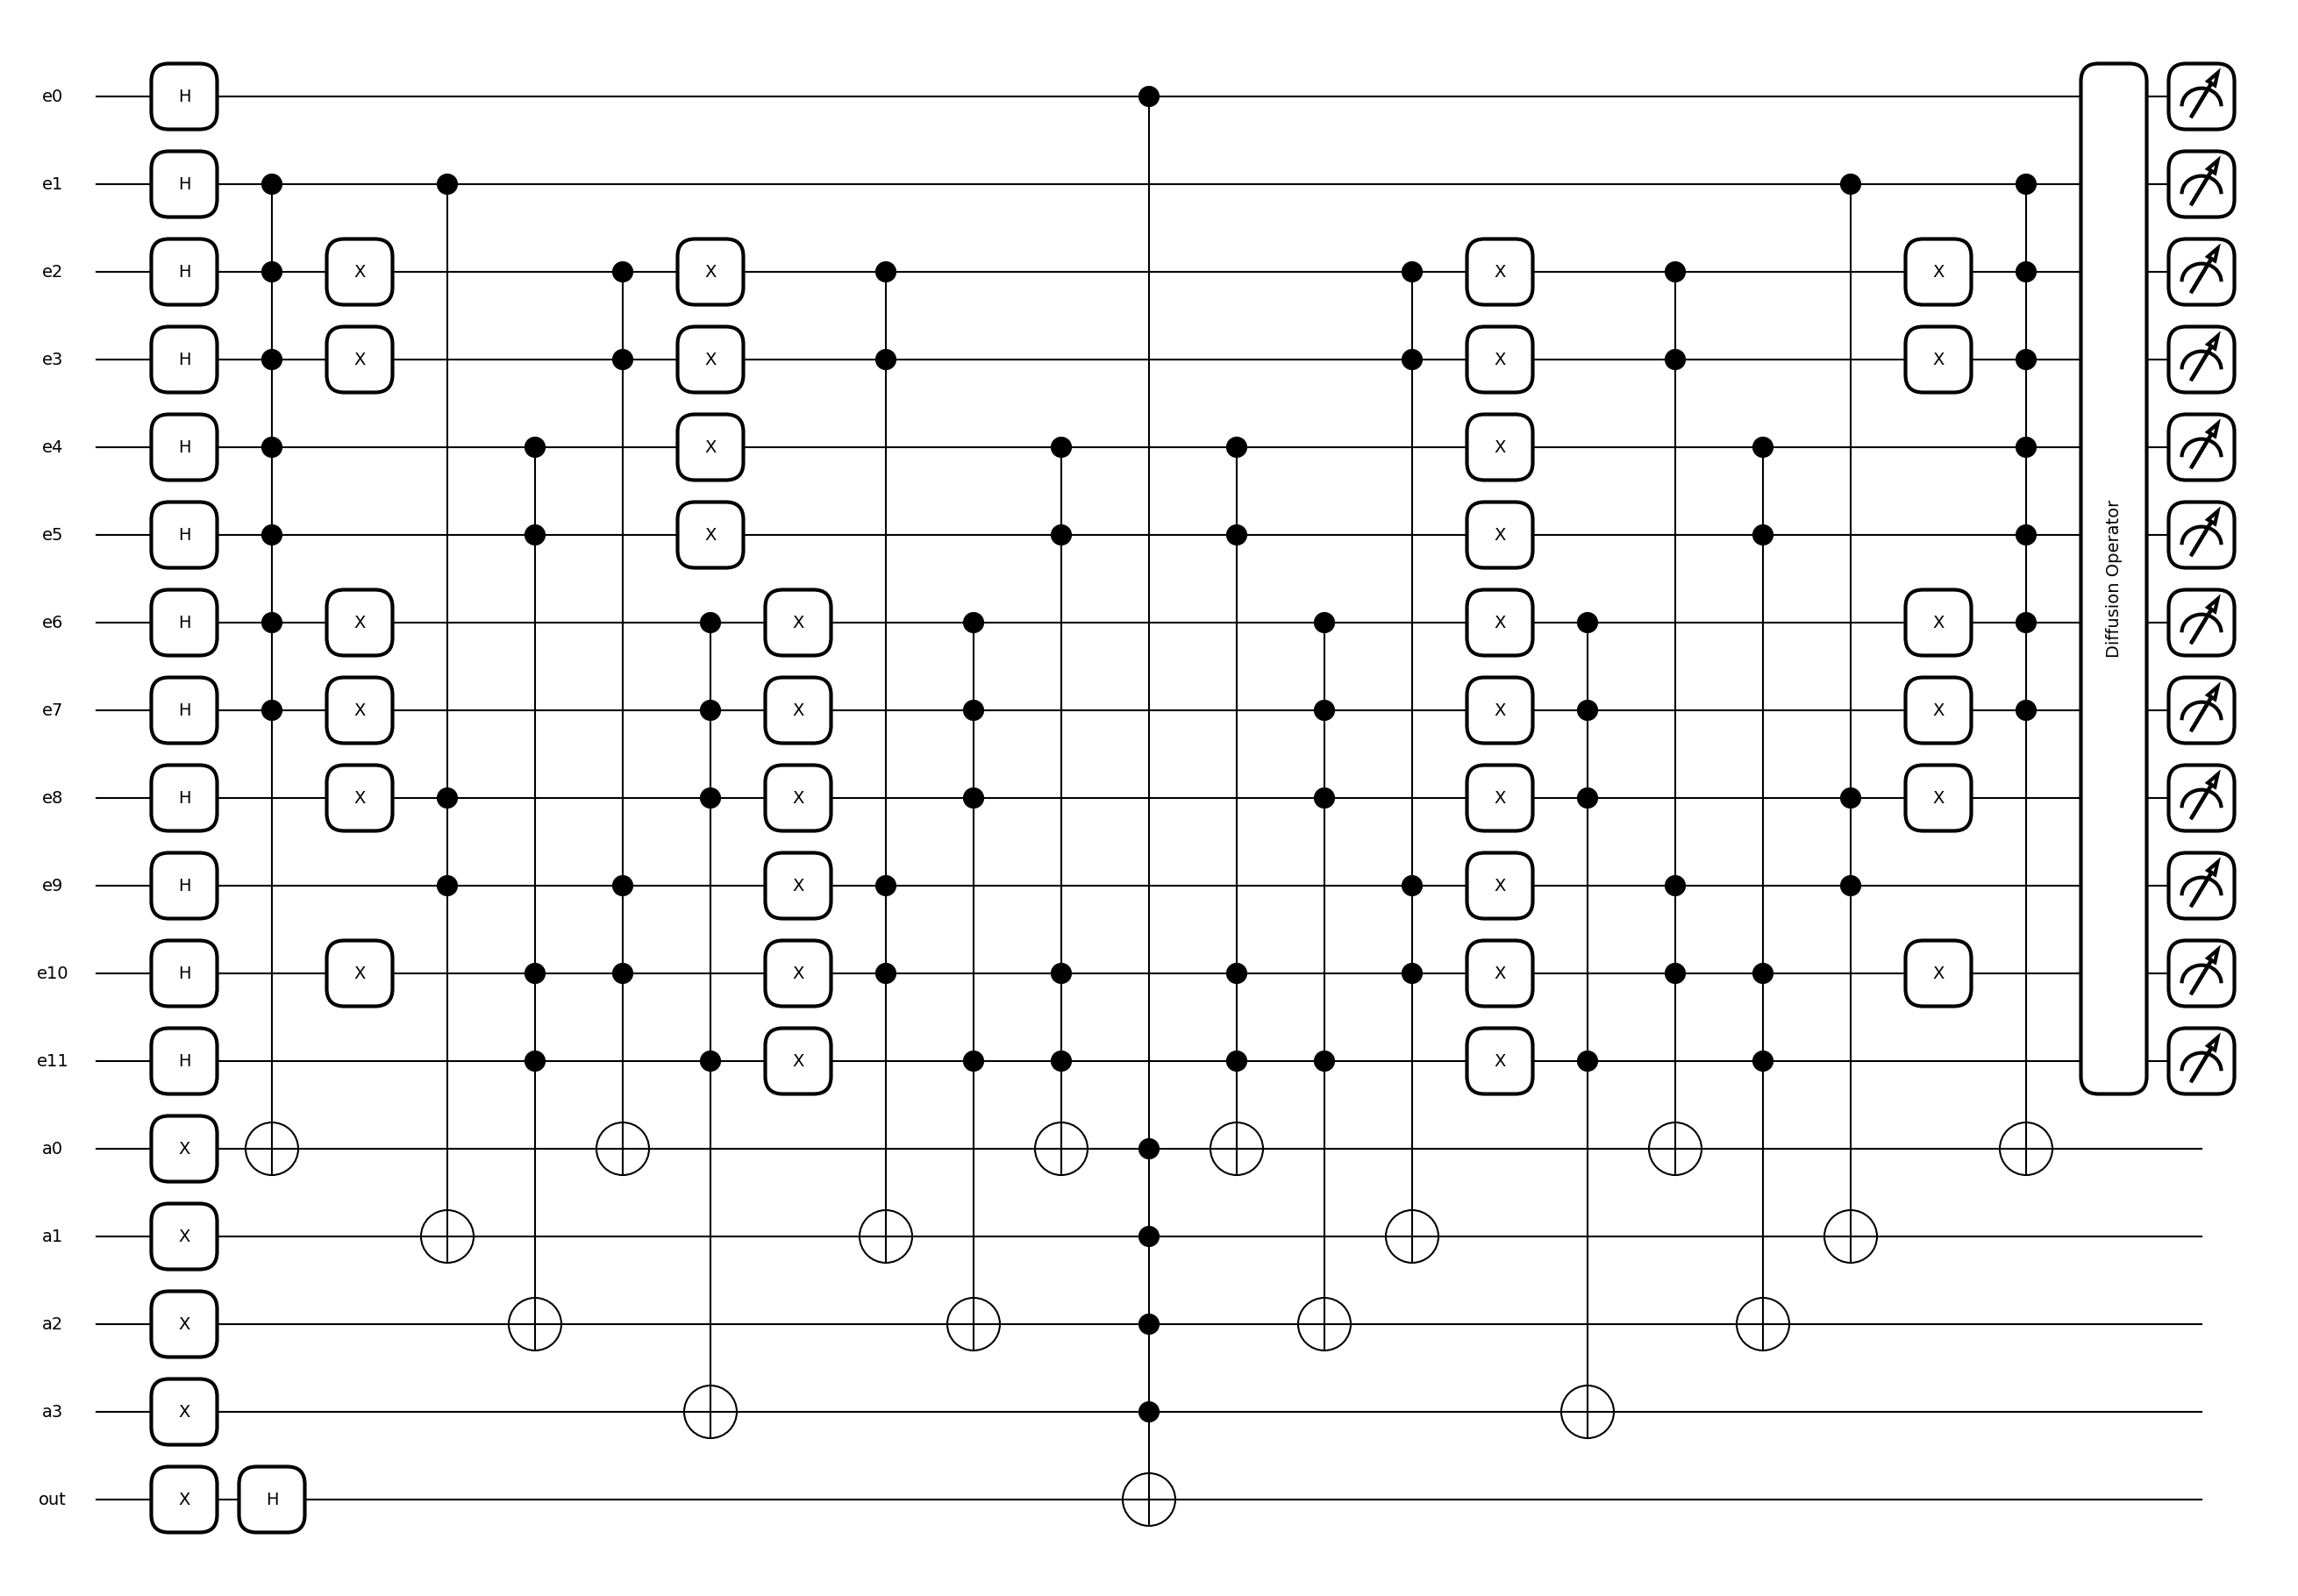

In [44]:
Draw_circuit(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [45]:
get_depth(circuit3)

The depth of the circuit is: 15


In [46]:
num_casual_states(circuit3(), cut = 300)

The number of casual states is: 1199


# Optimization

## OPTUNA

In [47]:
import itertools
import optuna
import math

# List of original subsets
subconjuntos_base = depth_combination3[0]


# Precomputes the permutations of each subset (as a list of tuples)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputes the number of permutations of each subset
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total amount of permutations with a subset order fixed
total_comb_internas = math.prod(num_permutaciones)

# Amount of subset permutations
total_ordenes = math.factorial(len(subconjuntos_base))

# Total amount of possible permutations (not all permutations are generated)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodes internal indices for each subset
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Constructs the last combination
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Executes the optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # Adjust the number of trials

# Shows the best value
best_idx = study.best_params["idx"]
best_combination = decodificar_combinacion(best_idx)
print("Best combination:", best_combination)
print("Minimum value:", study.best_value)


[I 2026-04-22 15:01:29,274] A new study created in memory with name: no-name-e2963ce0-a298-488e-be99-3a5912e7bb5e
[I 2026-04-22 15:01:29,295] Trial 0 finished with value: 17.0 and parameters: {'idx': 639}. Best is trial 0 with value: 17.0.
[I 2026-04-22 15:01:29,304] Trial 1 finished with value: 19.0 and parameters: {'idx': 255}. Best is trial 0 with value: 17.0.
[I 2026-04-22 15:01:29,313] Trial 2 finished with value: 19.0 and parameters: {'idx': 8}. Best is trial 0 with value: 17.0.
[I 2026-04-22 15:01:29,321] Trial 3 finished with value: 19.0 and parameters: {'idx': 727}. Best is trial 0 with value: 17.0.
[I 2026-04-22 15:01:29,330] Trial 4 finished with value: 23.0 and parameters: {'idx': 687}. Best is trial 0 with value: 17.0.
[I 2026-04-22 15:01:29,338] Trial 5 finished with value: 19.0 and parameters: {'idx': 457}. Best is trial 0 with value: 17.0.
[I 2026-04-22 15:01:29,348] Trial 6 finished with value: 21.0 and parameters: {'idx': 497}. Best is trial 0 with value: 17.0.
[I 202

Best combination: [[4], [2, 0, 5, 7], [3, 1, 6]]
Minimum value: 15.0


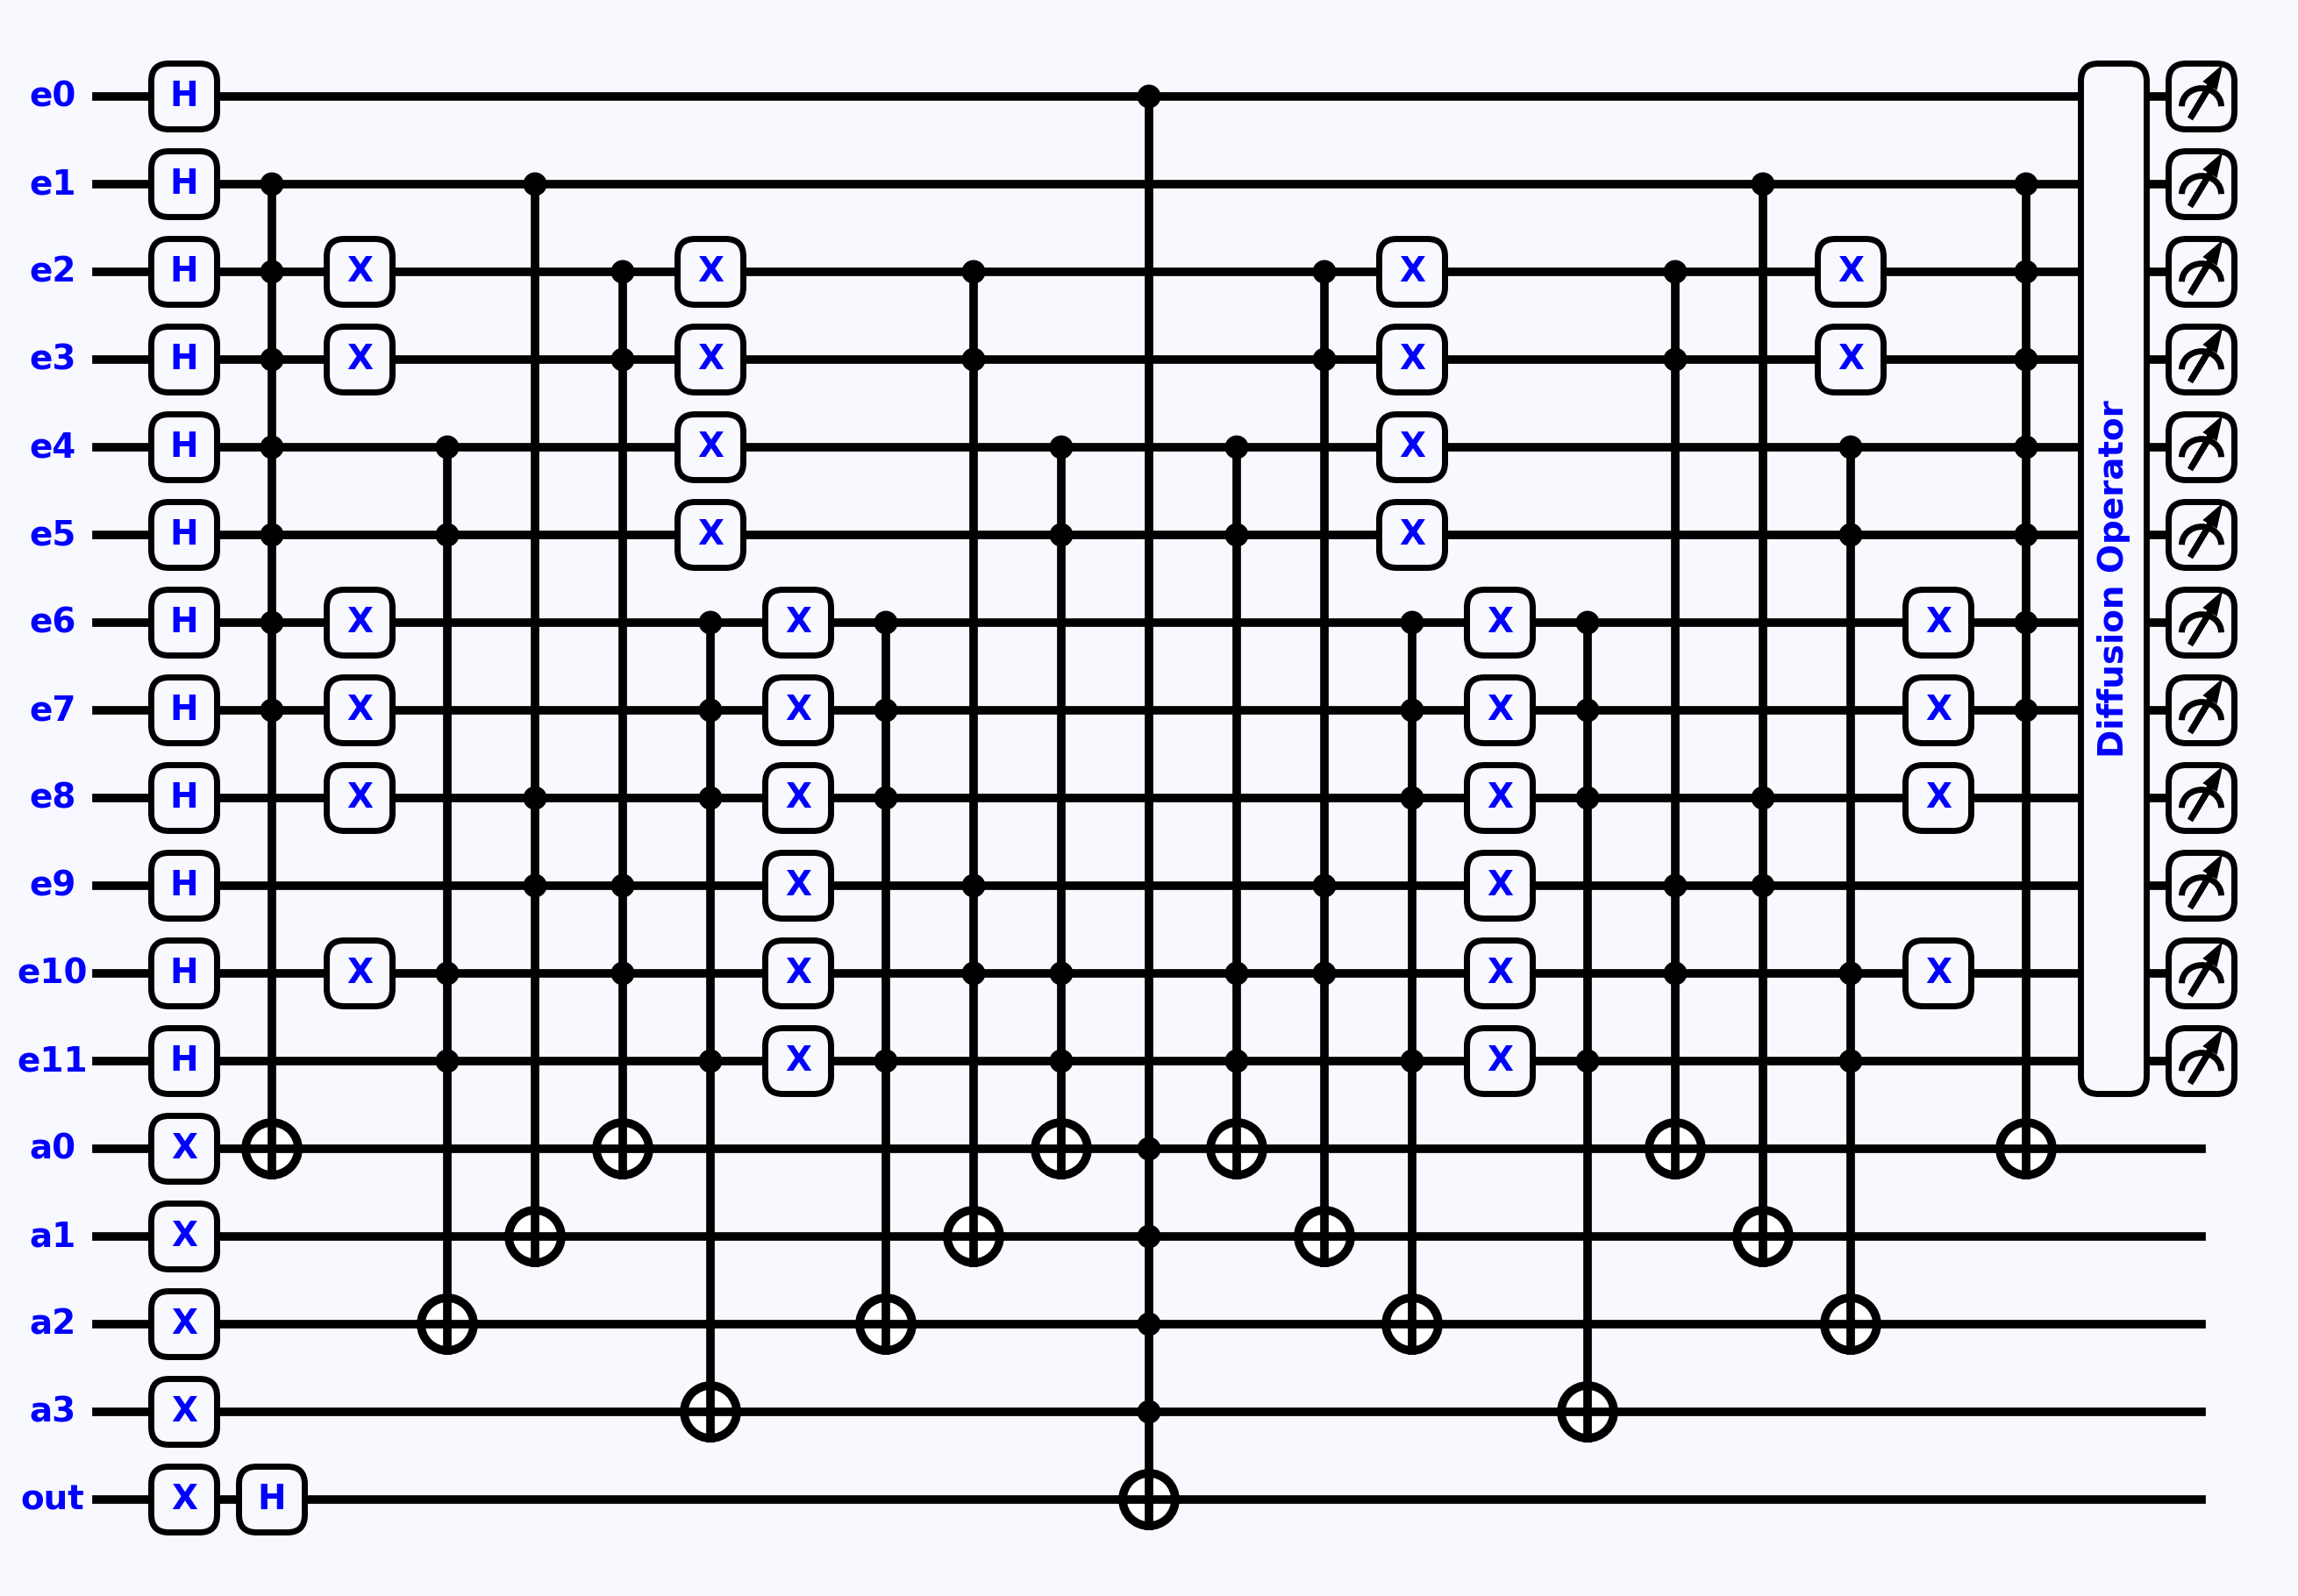

The depth of the circuit is: 15


In [48]:
circuit_D = circuit_function(best_combination)
Draw_circuit2(circuit_D, wire_order_list= total_wires, name_file = name_diagram)
get_depth(circuit_D)